# Laboratorio 5 - Parte 2. Máquinas de Vectores de Soporte

In [1]:
!wget -nc --no-cache -O init.py -q https://raw.githubusercontent.com/jdariasl/Intro_ML_2025/master/init.py
import init; init.init(force_download=False); init.get_weblink()

In [70]:
from local.lib.rlxmoocapi import submit, session
import inspect
session.LoginSequence(endpoint=init.endpoint, course_id=init.course_id, lab_id="L05.02", varname="student");

logging in as julian.ariasl@udea.edu.co... please wait

-------------
using course session introml::udea.pre.20251
success!! you are logged in
-------------


In [5]:
from Labs.commons.utils.lab5 import *
_, dataset = part_2()

Dim de la base de datos original: (2000, 13)


## Ejercicio 1: Limipiar base de datos y completar código

En este ejercicio usaremos la regresión por vectores de soporte para resolver el problema de regresión de la base de datos AirQuality (https://archive.ics.uci.edu/ml/datasets/Air+Quality). Tener en cuenta que vamos a usar solo 2000 muestras.

En primera instancia vamos a transformar la matriz en un dataframe, para poderlo procesar de manera mas sencilla. Se crea una columna por cada variable que obtenemos.

In [6]:
dataset_df = pd.DataFrame(dataset, columns = [f'col_{c}' for c in range (1,14)])

Para esta base de datos vamos a realizar una limpieza de datos.
Para ello vamos a completar la siguiente función para realizar:
    
1. **Remover** todos los registros cuya variable objetivo es faltante (missing Value). Estos registros están marcados como -200, es decir, donde haya un valor -200 eliminaremos el registro.
2. **imputar los valores perdidos/faltantes** en cada una de las características, vamos a usar el valor medio de la propia característica (estimado con las muestras que si cuentan con información en dicha variable) y lo usaremos para llenar los huecos. (será de utilidad conocer [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html))
3. **Verificar** si quedaron valores faltantes
4. **retornar** X (12 primeras columnas) y Y(la 13 columna).

información de utilidad:

1. Aca puede ser de utilidad revisar la [sesión extra](https://jdariasl.github.io/Intro_ML_2025/Labs/Extra/Basic_Preprocessing_FeatureEngineering.html).
2. Para transformar columnas de pandas a arreglos de numpy se puede usar `.iloc` / `.loc` y . `.values`, por ejemplo  para devolver una matriz con los valores de las primeras dos columnas es posible hacerlo asi: `dataset_df.iloc[: , 0:2].values` o `dataset_df.loc[: , ['col_1', 'col_2']].values`
3. Para cambiar valores faltantes, podemos usar la [librería sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html)

In [8]:
# TEACHER
dataset_df.head(5)

,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,col_11,col_12,col_13
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [14]:
# TEACHER
(dataset_df['col_3']==-200).sum()

np.int64(1086)

In [2]:
# ejercicio de codigo
def clean_data(df):
    """función que limpia el dataset y obtiene X y Y

    df: es un pandas dataframe

    retorna:
    X: una matriz numpy con los valores a usar como conjunto de datos
       de entrada
    Y una matriz numpy con los valores usados como conjunto de datos
       de salida

    """

    # se copia el df para evitar cambios sobre el objeto
    database = df.copy()

    ##Verificar
    pct_valores_faltantes = (database==-200).mean()
    print(",".join([f"% VF en {a}: {pct_valores_faltantes[a]*100:.2f}% " for a in pct_valores_faltantes.index]))

    # identificar y remover del data frame las muestras cuya salida es un valor faltante
    database = ...

    # Imprimir el número de muestras removidas
    print(...)

    print ("\nDim de la base de datos sin las muestras con variable de salida perdido "+ str(np.shape(database)))

    ##Imputar los valores de las características en el dataframe que tienen datos faltantes
    database = ...

    print ("Imputación finalizada.\n")

    ##Verificar
    pct_valores_faltantes = (database==-200).mean()

    print(",".join([f"% VF en {a}: {pct_valores_faltantes[a]*100:.2f}% " for a in pct_valores_faltantes.index]))

    if(pct_valores_faltantes.max() != 0):
        print ("Hay valores perdidos")
    else:
        print ("No hay valores perdidos en la base de datos. Ahora se puede procesar")

    X = database.iloc[:,0:12].values
    Y = database.iloc[:,12:13].values
    return (X,Y)

<>:37: SyntaxWarning: 'ellipsis' object is not callable; perhaps you missed a comma?
<>:37: SyntaxWarning: 'ellipsis' object is not callable; perhaps you missed a comma?
<ipython-input-2-a7dc1a22ba9f>:37: SyntaxWarning: 'ellipsis' object is not callable; perhaps you missed a comma?
  imputer = ... (missing_values= ... , strategy= ...)


In [180]:
## TEACHER
from local.lib.rlxmoocapi import submit, session
session.LoginSequence(endpoint=init.endpoint, course_id=init.course_id, lab_id="L05.02", varname="teacher");

logging in as julian.ariasl@udea.edu.co... please wait

-------------
using course session introml::udea.pre.20251
success!! you are logged in
-------------


In [ ]:
teacher = session.Session(init.endpoint).login(course_id=init.course_id, lab_id='L05.02', google_token=google_token)

In [65]:
## TEACHER DEFINEGRADER
def grader_01(functions, variables, caller_userid):
    import pandas as pd
    import numpy as np
    from sklearn.impute import SimpleImputer

    def t_clean_data(df):
        """función que limpia el dataset y obtiene X y Y

        df: es un pandas dataframe

        retorna:
        X: una matriz numpy con los valores a usar como conjunto de datos
          de entrada
        Y una matriz numpy con los valores usados como conjunto de datos
          de salida

        """

        # se copia el df para evitar cambios sobre el objeto
        database = df.copy()
        N = database.shape[0]

        ##Verificar
        pct_valores_faltantes = (database==-200).mean()
        print(",".join([f"% VF en {a}: {pct_valores_faltantes[a]*100:.2f}% " for a in pct_valores_faltantes.index]))


        #remover la muestras de los indices
        database = database[database['col_13'] != -200]

        print ("\nHay " + str(N - database.shape[0]) + " valores perdidos en la variable de salida.")
        print ("\nDim de la base de datos sin las muestras con variable de salida perdido "+ str(np.shape(database)))

        ##Imputar
        print ("\nProcesando imputación de valores perdidos en las características . . .")

        imp=SimpleImputer(missing_values=-200)
        "imputar solo las columnas de las variables de entrada"
        #database.iloc[:,0:...] = imputer.fit_transform(database.iloc[:,...] )
        idf=pd.DataFrame(imp.fit_transform(database))
        idf.columns=database.columns
        idf.index=database.index
        database=idf

        print ("Imputación finalizada teacher.\n")

        ##Verificar
        pct_valores_faltantes = (database==-200).mean()

        print(",".join([f"% VF en {a}: {pct_valores_faltantes[a]*100:.2f}% " for a in pct_valores_faltantes.index]))

        if(pct_valores_faltantes.max() != 0):
            print ("Hay valores perdidos")
        else:
            print ("No hay valores perdidos en la base de datos. Ahora se puede procesar")

        X = database.iloc[:,0:12].values
        Y = database.iloc[:,12:13].values
        return (X,Y)

    # retrieve definitions
    dataset_df = variables['dataset_df']

    namespace = locals()
    for f in functions.values():
        exec(f, namespace)



    s_clean_data = namespace['clean_data']

    msg =  "testing your code with random data points<br/>\n"


    X_t, y_t = t_clean_data(dataset_df)
    X_s, y_s = s_clean_data(dataset_df)

    if not np.allclose(X_t, X_s):
        msg += f"""
        <b>Incorrect implementation of clean_data</b>
        Expecting input samples <pre>{X_t}</pre> <br/>
        but got <pre>{X_s}</pre><br/>
        Check hyperparameter settings\n
        """
    if not np.allclose(y_t, y_s):
        msg += f"""
        <b>Incorrect implementation of clean_data</b>
        Expecting output variables <pre>{y_t}</pre> <br/>
        but got <pre>{y_s}</pre><br/>
        Check hyperparameter settings\n
        """

    return 5, msg + '<b>correct</b> ✅'

source_functions_names_01 = ['clean_data']
source_variables_names_01 = ['dataset_df']

In [66]:
# TEACHER
def clean_data(df):
    from sklearn.impute import SimpleImputer
    """función que limpia el dataset y obtiene X y Y

    df: es un pandas dataframe

    retorna:
    X: una matriz numpy con los valores a usar como conjunto de datos
       de entrada
    Y una matriz numpy con los valores usados como conjunto de datos
       de salida

    """

    # se copia el df para evitar cambios sobre el objeto
    database = df.copy()
    N = database.shape[0]

    ##Verificar
    pct_valores_faltantes = (database==-200).mean()
    print(",".join([f"% VF en {a}: {pct_valores_faltantes[a]*100:.2f}% " for a in pct_valores_faltantes.index]))


    #remover la muestras de los indices
    database = database[database['col_13'] != -200]

    print ("\nHay " + str(N - database.shape[0]) + " valores perdidos en la variable de salida.")
    print ("\nDim de la base de datos sin las muestras con variable de salida perdido "+ str(np.shape(database)))

    ##Imputar
    print ("\nProcesando imputación de valores perdidos en las características . . .")

    imp=SimpleImputer(missing_values=-200)
    "imputar solo las columnas de las variables de entrada"
    #database.iloc[:,0:...] = imputer.fit_transform(database.iloc[:,...] )
    idf=pd.DataFrame(imp.fit_transform(database))
    idf.columns=database.columns
    idf.index=database.index
    database=idf

    print ("Imputación finalizada student.\n")

    ##Verificar
    pct_valores_faltantes = (database==-200).mean()

    print(",".join([f"% VF en {a}: {pct_valores_faltantes[a]*100:.2f}% " for a in pct_valores_faltantes.index]))

    if(pct_valores_faltantes.max() != 0):
        print ("Hay valores perdidos")
    else:
        print ("No hay valores perdidos en la base de datos. Ahora se puede procesar")

    X = database.iloc[:,0:12].values
    Y = database.iloc[:,12:13].values
    return (X,Y)

In [74]:
# TEACHER
import inspect
teacher.run_grader_locally("grader_01", source_functions_names_01, source_variables_names_01, locals())

% VF en col_1: 20.00% ,% VF en col_2: 2.05% ,% VF en col_3: 54.30% ,% VF en col_4: 2.05% ,% VF en col_5: 2.05% ,% VF en col_6: 20.15% ,% VF en col_7: 2.05% ,% VF en col_8: 20.15% ,% VF en col_9: 2.05% ,% VF en col_10: 2.05% ,% VF en col_11: 2.05% ,% VF en col_12: 2.05% ,% VF en col_13: 2.05% 

Hay 41 valores perdidos en la variable de salida.

Dim de la base de datos sin las muestras con variable de salida perdido (1959, 13)

Procesando imputación de valores perdidos en las características . . .
Imputación finalizada teacher.

% VF en col_1: 0.00% ,% VF en col_2: 0.00% ,% VF en col_3: 0.00% ,% VF en col_4: 0.00% ,% VF en col_5: 0.00% ,% VF en col_6: 0.00% ,% VF en col_7: 0.00% ,% VF en col_8: 0.00% ,% VF en col_9: 0.00% ,% VF en col_10: 0.00% ,% VF en col_11: 0.00% ,% VF en col_12: 0.00% ,% VF en col_13: 0.00% 
No hay valores perdidos en la base de datos. Ahora se puede procesar
% VF en col_1: 20.00% ,% VF en col_2: 2.05% ,% VF en col_3: 54.30% ,% VF en col_4: 2.05% ,% VF en col_5: 2.0

In [73]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L05.02", 'T1',
                  inspect.getsource(grader_01), 'grader_01',
                  source_functions_names_01, source_variables_names_01)

**Registra tu solución en línea**

In [71]:
student.submit_task(namespace=globals(), task_id='T1');

Ahora usemos la función para tener nuestras variables X, Y

In [72]:
X,Y = clean_data(dataset_df)

% VF en col_1: 20.00% ,% VF en col_2: 2.05% ,% VF en col_3: 54.30% ,% VF en col_4: 2.05% ,% VF en col_5: 2.05% ,% VF en col_6: 20.15% ,% VF en col_7: 2.05% ,% VF en col_8: 20.15% ,% VF en col_9: 2.05% ,% VF en col_10: 2.05% ,% VF en col_11: 2.05% ,% VF en col_12: 2.05% ,% VF en col_13: 2.05% 

Hay 41 valores perdidos en la variable de salida.

Dim de la base de datos sin las muestras con variable de salida perdido (1959, 13)

Procesando imputación de valores perdidos en las características . . .
Imputación finalizada student.

% VF en col_1: 0.00% ,% VF en col_2: 0.00% ,% VF en col_3: 0.00% ,% VF en col_4: 0.00% ,% VF en col_5: 0.00% ,% VF en col_6: 0.00% ,% VF en col_7: 0.00% ,% VF en col_8: 0.00% ,% VF en col_9: 0.00% ,% VF en col_10: 0.00% ,% VF en col_11: 0.00% ,% VF en col_12: 0.00% ,% VF en col_13: 0.00% 
No hay valores perdidos en la base de datos. Ahora se puede procesar


### Ejercicio 2: Experimentar SVM para regresión

Ahora vamos a crear una función para experimentar con la maquina de soporte vectorial. Para ello debemos hacer lo siguiente:
1. Revisar la documentación de la clase de objetos que vamos a usar (ver  [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html).
2. Vamos a evaluar el efecto de tres hiperparámetros del SVR: kernel,  gamma y el parámetro de regularización, por lo tanto debemos comprender la relación con el modelo y su efecto.
3. El número máximo de iteraciones debe ser ajustado a 200
4. Utilizar la metodología cross-validation con 4 folds.
5. Usar normalización de datos estandar implementada por sklearn
6. Extraer los vectores de soporte (observe los *atributos* del modelo SVR de sklearn). Recuerde que estos atributos son accesibles, una vez el modelo es entrenado
7. Utilizar la métrica para calcular el MAPE (usar sklearn).


In [ ]:
#ejercicio de código
def experiementarSVR(x, y, kernels, gammas,params_reg):
    """función que realizar experimentos sobre una SVM para regresión

    x: numpy.Array, con las muestras del problema
    y: numpy.Array, con la variable objetivo
    kernels: List[str], lista con valores a pasar
        a sklearn correspondiente al kernel de la SVM
    gammas: List[float], lista con los valores a pasar a
        sklearn correspondientes al valor de los coeficientes para usar en el
        kernel
    params_reg: List[float], lista con los valores a pasar a
        sklearn para ser usados como parámetro de regularización

    retorna: pd.Dataframe con las siguientes columnas:
        - 3 columnas con los tres parametros: kernel, gamma, param de regularizacion
        - porcentaje de error absoluto medio en el cojunto test (promedio de los 4 folds)
        - intervalo de confianza del porcentaje de error absoluto medio en el cojunto test
            (desviacion estandar de los 4 folds)
        - # de Vectores de Soporte promedio para los 4 folds
        - % de Vectores de Soporte promedio para los 4 folds (0 a 100)
    """
    idx = 0
    kf = ...(n_splits=...)
    # crear una lista con la combinaciones de los elementos de cada list
    kernels_gammas_regs = list(itertools.product(kernels, gammas, params_reg))
    resultados = pd.DataFrame()

    for params in kernels_gammas_regs:
        kernel, gamma, param_reg = params
        print("parametros usados", params) # puede usar para ver los params
        errores_test = []
        pct_support_vectors = []
        num_support_vectors = []
        for train_index, test_index in kf...(...):

            X_train, X_test = x[train_index], x[test_index]
            y_train, y_test = y[train_index], y[test_index]
            # normalizar los datos
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            #Definir y entrenar el modelo

            svr = ...

            # Validación del modelo
            ypred = svr.predict(X=...)

            # MAPE de prueba
            errores_test.append(...)

            # Encontrar el número de vectores de soporte y el calcular el porcentaje que representan

            num_vs =
            pct_vs =


            pct_support_vectors.append(pct_vs)
            num_support_vectors.append(num_vs)

        resultados.loc[idx,'kernel'] = kernel
        resultados.loc[idx,'gamma'] = gamma
        resultados.loc[idx,'param_reg'] = param_reg
        resultados.loc[idx,'error de prueba (promedio)'] = np.mean(...)
        resultados.loc[idx,'error de prueba (intervalo de confianza)'] = np.std()
        resultados.loc[idx,'# de vectores de soporte'] = np.mean(...)
        resultados.loc[idx,'% de vectores de soporte'] = np.mean(...)

        idx+=1
    return (resultados)

In [189]:
## TEACHER DEFINEGRADER
def grader_02(functions, variables, caller_userid):
    import pandas as pd
    import numpy as np
    import itertools
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import KFold
    from sklearn.svm import SVR
    from sklearn.metrics import mean_absolute_percentage_error

    def t_experiementarSVR(x, y, kernels, gammas,params_reg):
      """función que realizar experimentos sobre una SVM para regresión

      x: numpy.Array, con las muestras del problema
      y: numpy.Array, con la variable objetivo
      kernels: List[str], lista con valores a pasar
          a sklearn correspondiente al kernel de la SVM
      gammas: List[float], lista con los valores a pasar a
          sklearn correspondientes al valor de los coeficientes para usar en el
          kernel
      params_reg: List[float], lista con los valores a pasar a
          sklearn para ser usados como parámetro de regularización

      retorna: pd.Dataframe con las siguientes columnas:
          - 3 columnas con los tres parametros: kernel, gamma, param de regularizacion
          - porcentaje de error absoluto medio en el cojunto test (promedio de los 4 folds)
          - intervalo de confianza del porcentaje de error absoluto medio en el cojunto test
              (desviacion estandar de los 4 folds)
          - # de Vectores de Soporte promedio para los 4 folds
          - % de Vectores de Soporte promedio para los 4 folds (0 a 100)
      """
      idx = 0
      kf = KFold(n_splits=4)
      # crear una lista con la combinaciones de los elementos de cada list
      kernels_gammas_regs = list(itertools.product(kernels, gammas, params_reg))
      resultados = pd.DataFrame()

      for params in kernels_gammas_regs:
          kernel, gamma, param_reg = params
          print("parametros usados", params) # puede usar para ver los params
          errores_test = []
          pct_support_vectors = []
          num_support_vectors = []
          for train_index, test_index in kf.split(x,y):

              X_train, X_test = x[train_index], x[test_index]
              y_train, y_test = y[train_index], y[test_index]
              # normalizar los datos
              scaler = StandardScaler()
              X_train = scaler.fit_transform(X_train)
              X_test = scaler.transform(X_test)
              svm = SVR(kernel = kernel, gamma = gamma, C = param_reg, max_iter=200)
              # Entrenar el modelo
              svm.fit(X=X_train, y=y_train)
              # Validación del modelo
              ypred = svm.predict(X=X_test)

              # error y pct de vectores de soporte
              errores_test.append(mean_absolute_percentage_error(y_true = y_test, y_pred = ypred))
              # contar muestras de entrenamiento
              n_train = X_train.shape[0]
              num_vs = len(svm.support_)
              pct_vs = (num_vs / n_train ) *100
              pct_support_vectors.append(pct_vs)
              num_support_vectors.append(num_vs)

          resultados.loc[idx,'kernel'] = kernel
          resultados.loc[idx,'gamma'] = gamma
          resultados.loc[idx,'param_reg'] = param_reg
          resultados.loc[idx,'error de prueba (promedio)'] = np.mean(errores_test)
          resultados.loc[idx,'error de prueba (intervalo de confianza)'] = np.std(errores_test)
          resultados.loc[idx,'# de vectores de soporte'] = np.mean(num_support_vectors)
          resultados.loc[idx,'% de vectores de soporte'] = np.mean(pct_support_vectors)

          idx+=1
      return (resultados)

    # retrieve definitions
    namespace = locals()
    for f in functions.values():
        exec(f, namespace)

    s_experiementarSVR = namespace['experiementarSVR']

    msg =  "testing your code with random data points<br/>\n"
    kernels=['linear', 'rbf']
    gammas = [0.01,0.1]
    params_reg = [0.1, 1.0,10]
    for _ in range(4):  # Puedes ajustar el número de iteraciones según sea necesario
        input_dim = np.random.randint(5)+5
        input_n = np.random.randint(500) + 20
        X = np.random.randn(input_n, input_dim).astype('f')
        y = np.y = np.random.randn(input_n, 1).astype('f')


        t_resultados = t_experiementarSVR(X,y,kernels,gammas,params_reg)[['error de prueba (promedio)','error de prueba (intervalo de confianza)','# de vectores de soporte','% de vectores de soporte']].values
        s_resultados = s_experiementarSVR(X,y,kernels,gammas,params_reg)[['error de prueba (promedio)','error de prueba (intervalo de confianza)','# de vectores de soporte','% de vectores de soporte']].values

        if not np.allclose(t_resultados, s_resultados):
            msg += f"""
            <b>Incorrect experiment results</b>
            Expecting result <pre>{t_resultados}</pre> <br/>
            but got <pre>{s_resultados}</pre><br/>
            Check hyperparameter settings\n
            """
            return 0, msg

    return 5, msg + '<b>correct</b> ✅'

source_functions_names_02 = ['experiementarSVR']
source_variables_names_02 = []

In [190]:
# TEACHER
def experiementarSVR(x, y, kernels, gammas,params_reg):
    """función que realizar experimentos sobre una SVM para regresión

    x: numpy.Array, con las muestras del problema
    y: numpy.Array, con la variable objetivo
    kernels: List[str], lista con valores a pasar
        a sklearn correspondiente al kernel de la SVM
    gammas: List[float], lista con los valores a pasar a
        sklearn correspondientes al valor de los coeficientes para usar en el
        kernel
    params_reg: List[float], lista con los valores a pasar a
        sklearn para ser usados como parámetro de regularización

    retorna: pd.Dataframe con las siguientes columnas:
        - 3 columnas con los tres parametros: kernel, gamma, param de regularizacion
        - porcentaje de error absoluto medio en el cojunto test (promedio de los 4 folds)
        - intervalo de confianza del porcentaje de error absoluto medio en el cojunto test
            (desviacion estandar de los 4 folds)
        - # de Vectores de Soporte promedio para los 4 folds
        - % de Vectores de Soporte promedio para los 4 folds (0 a 100)
    """
    idx = 0
    kf = KFold(n_splits=4)
    # crear una lista con la combinaciones de los elementos de cada list
    kernels_gammas_regs = list(itertools.product(kernels, gammas, params_reg))
    resultados = pd.DataFrame()

    for params in kernels_gammas_regs:
        kernel, gamma, param_reg = params
        print("parametros usados", params) # puede usar para ver los params
        errores_test = []
        pct_support_vectors = []
        num_support_vectors = []
        for train_index, test_index in kf.split(x,y):

            X_train, X_test = x[train_index], x[test_index]
            y_train, y_test = y[train_index], y[test_index]
            # normalizar los datos
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
            svm = SVR(kernel = kernel, gamma = gamma, C = param_reg, max_iter=200)
            # Entrenar el modelo
            svm.fit(X=X_train, y=y_train)
            # Validación del modelo
            ypred = svm.predict(X=X_test)

            # error y pct de vectores de soporte
            errores_test.append(mean_absolute_percentage_error(y_true = y_test, y_pred = ypred))
            # contar muestras de entrenamiento
            n_train = X_train.shape[0]
            num_vs = len(svm.support_)
            pct_vs = (num_vs / n_train ) *100
            pct_support_vectors.append(pct_vs)
            num_support_vectors.append(num_vs)

        resultados.loc[idx,'kernel'] = kernel
        resultados.loc[idx,'gamma'] = gamma
        resultados.loc[idx,'param_reg'] = param_reg
        resultados.loc[idx,'error de prueba (promedio)'] = np.mean(errores_test)
        resultados.loc[idx,'error de prueba (intervalo de confianza)'] = np.std(errores_test)
        resultados.loc[idx,'# de vectores de soporte'] = np.mean(num_support_vectors)
        resultados.loc[idx,'% de vectores de soporte'] = np.mean(pct_support_vectors)

        idx+=1
    return (resultados)

In [191]:
# TEACHER
import inspect
teacher.run_grader_locally("grader_02", source_functions_names_02, source_variables_names_02, locals())

parametros usados ('linear', 0.01, 0.1)
parametros usados ('linear', 0.01, 1.0)
parametros usados ('linear', 0.01, 10)
parametros usados ('linear', 0.1, 0.1)
parametros usados ('linear', 0.1, 1.0)
parametros usados ('linear', 0.1, 10)
parametros usados ('rbf', 0.01, 0.1)
parametros usados ('rbf', 0.01, 1.0)
parametros usados ('rbf', 0.01, 10)
parametros usados ('rbf', 0.1, 0.1)
parametros usados ('rbf', 0.1, 1.0)
parametros usados ('rbf', 0.1, 10)
parametros usados ('linear', 0.01, 0.1)
parametros usados ('linear', 0.01, 1.0)
parametros usados ('linear', 0.01, 10)
parametros usados ('linear', 0.1, 0.1)
parametros usados ('linear', 0.1, 1.0)
parametros usados ('linear', 0.1, 10)
parametros usados ('rbf', 0.01, 0.1)
parametros usados ('rbf', 0.01, 1.0)
parametros usados ('rbf', 0.01, 10)
parametros usados ('rbf', 0.1, 0.1)
parametros usados ('rbf', 0.1, 1.0)
parametros usados ('rbf', 0.1, 10)
parametros usados ('linear', 0.01, 0.1)
parametros usados ('linear', 0.01, 1.0)
parametros usado

In [123]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L05.02", 'T2',
                  inspect.getsource(grader_02), 'grader_02',
                  source_functions_names_02, source_variables_names_02)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T2');

Para entrenar vamos a ignorar las dos primeras variables, estas corresponden a valores de fechas.

In [106]:
# vamos a realizar los experimentos
resultadosSVR = experiementarSVR(x =X[:,2:],y=Y,
                                 kernels=['linear', 'rbf'],
                                 gammas = [0.01,0.1],
                                 params_reg = [0.1, 1.0,10]
                                )

parametros usados ('linear', 0.01, 0.1)
parametros usados ('linear', 0.01, 1.0)
parametros usados ('linear', 0.01, 10)
parametros usados ('linear', 0.1, 0.1)
parametros usados ('linear', 0.1, 1.0)
parametros usados ('linear', 0.1, 10)
parametros usados ('rbf', 0.01, 0.1)
parametros usados ('rbf', 0.01, 1.0)
parametros usados ('rbf', 0.01, 10)
parametros usados ('rbf', 0.1, 0.1)
parametros usados ('rbf', 0.1, 1.0)
parametros usados ('rbf', 0.1, 10)


In [107]:
# ver los 5 primeros resultados
resultadosSVR.sort_values('error de prueba (promedio)',ascending=True).head(5)

,kernel,gamma,param_reg,error de prueba (promedio),error de prueba (intervalo de confianza),# de vectores de soporte,% de vectores de soporte
8,rbf,0.01,10.0,0.050252,0.004954,25.75,1.752638
7,rbf,0.01,1.0,0.053959,0.011259,54.75,3.726527
3,linear,0.10,0.1,0.055444,0.010731,96.75,6.585569
0,linear,0.01,0.1,0.055444,0.010731,96.75,6.585569
4,linear,0.10,1.0,0.055682,0.010684,97.75,6.653654


In [108]:
#@title Pregunta Abierta
#@markdown ¿Cual es el objetivo de las las funciones kernel? Contestar dentro del contexto de las máquinas de sporte vectorial
respuesta = "" #@param {type:"string"}

In [109]:
#@title Pregunta Abierta
#@markdown Existe alguna relación entre el porcentaje de vectores de soporte y error esperado?
respuesta = "" #@param {type:"string"}

Para analizar los resultados vamos a crear dos graficas para el mejor modelo encontrado:
1. vamos a graficar en el eje x el valor real, en el eje y el valor predicho. El modelo ideal deberia ser una recta que recuerda la identidad
2. en el eje x vamos a dejar un valor incremental y con colores vamos a diferenciar entre el valor real y el valor predicho



In [ ]:
# dividir el conjunto
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#predicciones
# OJO: Completar!
Ypred =  predict_svr(X_train,y_train,X_test,kernel = ..., )

# plots

f, ax = plt.subplots(ncols=2, sharex=False, sharey=False, figsize = (22,6))
ax[0].scatter(y_test, Ypred)
ax[0].set_xlabel('valor real', fontdict = {'fontsize': 12})
ax[0].set_ylabel('valor predicho', fontdict = {'fontsize': 12})
ax[1].plot(y_test, label = 'valor real', color = 'b', alpha = 0.7)
ax[1].plot(Ypred, label = 'valor predicho', color = 'r', alpha = 0.5)
ax[1].legend()
ax[1].set_ylabel('Humedad relativa', fontdict = {'fontsize': 12})
plt.show()

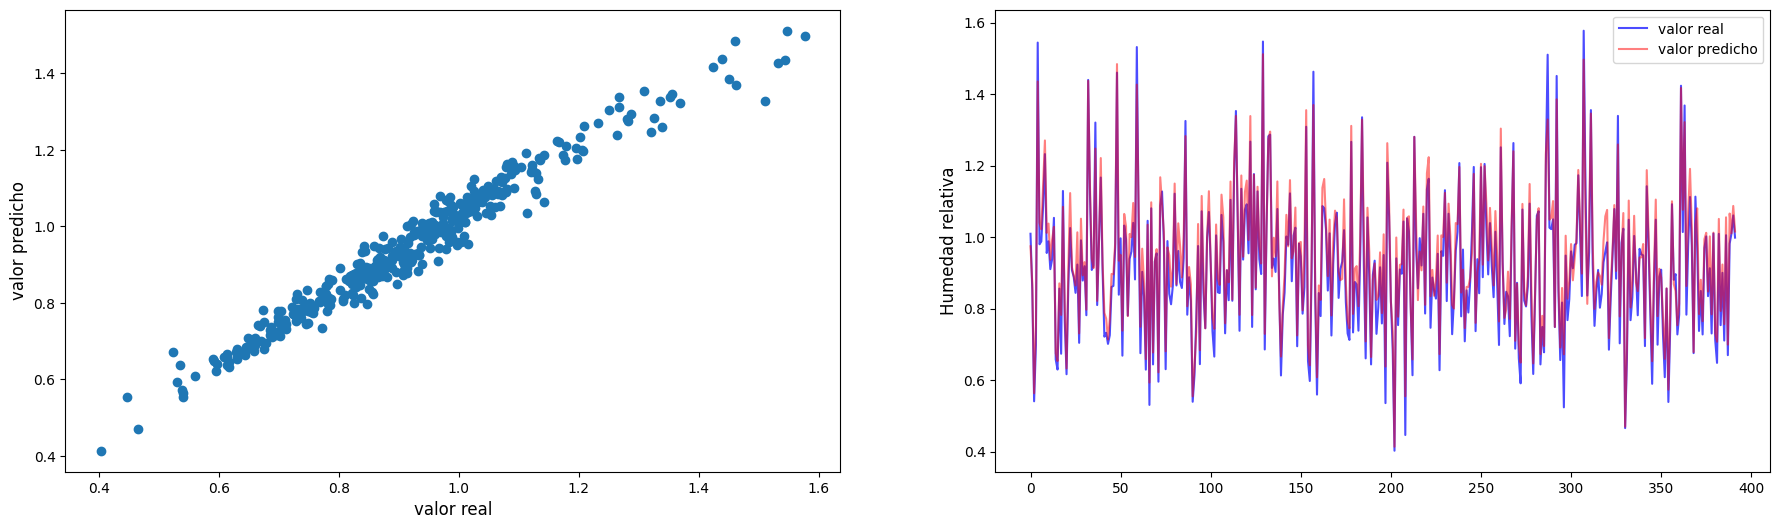

In [111]:
# TEACHER
# dividir el conjunto
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#predicciones
# OJO: Reemplazar los valores!
svr = SVR(kernel = 'rbf', gamma = 0.01, C = 10)
svr.fit(X=X_train, y=y_train)
Ypred =  svr.predict(X_test)

# plots

f, ax = plt.subplots(ncols=2, sharex=False, sharey=False, figsize = (22,6))
ax[0].scatter(y_test, Ypred)
ax[0].set_xlabel('valor real', fontdict = {'fontsize': 12})
ax[0].set_ylabel('valor predicho', fontdict = {'fontsize': 12})
ax[1].plot(y_test, label = 'valor real', color = 'b', alpha = 0.7)
ax[1].plot(Ypred, label = 'valor predicho', color = 'r', alpha = 0.5)
ax[1].legend()
ax[1].set_ylabel('Humedad relativa', fontdict = {'fontsize': 12})
plt.show()

In [112]:
#@title Pregunta Abierta
#@markdown usando las anteriores graficas, ¿como calificaría el modelo de manera cualitativa?.
respuesta = "" #@param {type:"string"}

## Ejercicio 3: Experimentar SVM para clasificación

En este ejercicio vamos a volver a resolver el problema de clasificación de dígitos. Vamos usar solo 5 clases y realizaremos un pre-procesamiento:
1. Mediante PCA reduciremos la dimensionalidad de los datos
2. Vamos a convertir el problema en uno de cuatro clases (diferenciar entre 0, 1, 2 y el resto)

In [232]:
Xcl, Ycl = load_digits(n_class=5,return_X_y=True)
#--------- preprocesamiento--------------------
pca = PCA(0.99, whiten=True)
Xcl = pca.fit_transform(Xcl)
# cambiar problema de clases
unique, counts  = np.unique(Ycl, return_counts=True)
print("distribución original (claves las etiquetas, valores el número de muestras): \n", dict(zip(unique, counts )))
Ycl = np.where(np.isin(Ycl, [0,1,2]), Ycl, 3)
unique, counts  = np.unique(Ycl, return_counts=True)
print("Nueva distribución  (claves las etiquetas, valores el número de muestras): \n", dict(zip(unique, counts )))

distribución original (claves las etiquetas, valores el número de muestras): 
 {np.int64(0): np.int64(178), np.int64(1): np.int64(182), np.int64(2): np.int64(177), np.int64(3): np.int64(183), np.int64(4): np.int64(181)}
Nueva distribución  (claves las etiquetas, valores el número de muestras): 
 {np.int64(0): np.int64(178), np.int64(1): np.int64(182), np.int64(2): np.int64(177), np.int64(3): np.int64(364)}


Ahora vamos a crear la función para experimentar con la máquina de soporte vectorial. Los parámetros de la prueba y sus requerimientos se listan a continuación:

1. Revisar la documentación correspondiente al modelo [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC)
2. Realizaremos pruebas para ajustar tres hiperparámetros del SVC: kernel,  gamma y el parametro de regularización.
3. El número máximo de iteraciones será ajustado a 500
4. Seleccionar una metodología de cross-validation con 4 folds adecuada para la distribución de datos.
5. Usar normalización de datos estandar implementada por sklearn
6. Extraer los vectores de soporte (observe los *atributos* del modelo SVC de sklearn). Recuerde que estos atributos son accesibles una vez el modelo es entrenado
7. vamos a probar la dos estragegias multiclase básicas del SVC:
    - One Vs One (ver [link](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsOneClassifier.html))
    - One Vs Rest (ver [link](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html))
8. Utilizar como medida de desempeño el score de exactitud de sklearn.

In [ ]:
#ejercicio de código
def experiementarSVC(x, y, kernels, gammas,params_reg, estrategia = 'ovo'):
    """función que realizar experimentos sobre un SVM para clasificación

    x: numpy.Array, con los datos de entrada del problema
    y: numpy.Array, con la variable objetivo
    kernels: List[str], lista con valores a pasar
        a sklearn correspondiente al kernel de la SVM
    gammas: List[float], lista con los valores a pasar a
        sklean correspondiente el valor de los coeficientes para usar en el
        kernel
    params_reg: List[float], lista con los valores a a pasar a
        sklearn para ser usados como parametro de regularización
    estrategia: str, valor que puede ser ovo (para one vs one) o ovr
        (para one vs rest)

    retorna: pd.Dataframe con las siguientes columnas:
        - 3 columnas con los tres parametros: kernel, gamma, param de regularizacion
        - estrategia de clasificación (ovo o ovr)
        - Error en el conjunto de entrenamiento (promedio de los 4 folds)
        - Error en el conjunto de test (promedio de los 4 folds)
        - % de Vectores de Soporte promedio para los 4 folds (0 a 100)
    """
    idx = 0
    kf = ...(n_splits=...)
    # crear una lista con la combinaciones de los elementos de cada list
    kernels_gammas_regs = list(itertools.product(kernels, gammas, params_reg))
    resultados = pd.DataFrame()

    for params in kernels_gammas_regs:
        kernel, gamma, param_reg = params
        print("parametros usados", params) # puede usar para ver los params
        errores_train = []
        errores_test = []
        pct_support_vectors = []

        for train_index, test_index in kf...(...,...):
            X_train, X_test = x[train_index], x[test_index]
            y_train, y_test = y[train_index], y[test_index]
            # normalizar los datos
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            #Instanciar y entrenar el modelo con los hiperparámetros adecuados
            svm = ...

            # calculo de errores
            y_train_pred = ...
            y_test_pred = ...

            # error y pct de vectores de soporte
            errores_train.append(1 - accuracy_score(y_true = y_train, y_pred = y_train_pred))
            errores_test.append(1 - accuracy_score(y_true = y_test, y_pred = y_test_pred))

            # Calcular el porcentaje de vectores de soporte. Tenga en cuenta que las estrategias
            # OVO y OVR implican el entrenamiento de varios modelos. En este caso se debe estimar
            # el promedio de porcentajes de vectores de soporte dentro de los estimadores que hacen parte de
            # la estrategia multiclase y promediarlos.
            pct_vs = ...

            pct_support_vectors.append(pct_vs)

        resultados.loc[idx,'kernel'] = kernel
        resultados.loc[idx,'gamma'] = gamma
        resultados.loc[idx,'param_reg'] = param_reg
        resultados.loc[idx,'estrategia'] = ...
        resultados.loc[idx,'error de entrenamiento'] = np.mean()
        resultados.loc[idx,'error de prueba'] = np.mean()
        resultados.loc[idx,'% de vectores de soporte'] = np.mean(...)
        idx+=1
    return (resultados)

In [199]:
## TEACHER DEFINEGRADER
def grader_03(functions, variables, caller_userid):
    import pandas as pd
    import numpy as np
    import itertools
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import KFold, StratifiedKFold
    from sklearn.svm import SVC
    from sklearn.metrics import accuracy_score
    from sklearn.multiclass import OneVsRestClassifier
    from sklearn.multiclass import OneVsOneClassifier

    def t_experiementarSVC(x, y, kernels, gammas,params_reg, estrategia = 'ovo'):
        """función que realizar experimentos sobre un SVM para clasificación

        x: numpy.Array, con los datos de entrada del problema
        y: numpy.Array, con la variable objetivo
        kernels: List[str], lista con valores a pasar
            a sklearn correspondiente al kernel de la SVM
        gammas: List[float], lista con los valores a pasar a
            sklean correspondiente el valor de los coeficientes para usar en el
            kernel
        params_reg: List[float], lista con los valores a a pasar a
            sklearn para ser usados como parametro de regularización
        estrategia: str, valor que puede ser ovo (para one vs one) o ovr
            (para one vs rest)

        retorna: pd.Dataframe con las siguientes columnas:
            - 3 columnas con los tres parametros: kernel, gamma, param de regularizacion
            - estrategia de clasificación (ovo o ovr)
            - Error en el conjunto de entrenamiento (promedio de los 4 folds)
            - Error en el conjunto de test (promedio de los 4 folds)
            - % de Vectores de Soporte promedio para los 4 folds (0 a 100)
        """
        idx = 0
        kf = StratifiedKFold(n_splits=4)
        # crear una lista con la combinaciones de los elementos de cada list
        kernels_gammas_regs = list(itertools.product(kernels, gammas, params_reg))
        resultados = pd.DataFrame()

        for params in kernels_gammas_regs:
            kernel, gamma, param_reg = params
            print("parametros usados", params) # puede usar para ver los params
            errores_train = []
            errores_test = []
            pct_support_vectors = []

            for train_index, test_index in kf.split(x,y):
                X_train, X_test = x[train_index], x[test_index]
                y_train, y_test = y[train_index], y[test_index]

                # normalizar los datos
                scaler = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)

                #Instanciar y entrenar el modelo con los hiperparámetros adecuados
                svm = SVC(kernel = kernel, gamma = gamma, C = param_reg, max_iter=500)

                if estrategia == 'ovo':
                    svm = OneVsOneClassifier(svm)
                elif estrategia == 'ovr':
                    svm = OneVsRestClassifier(svm)
                svm.fit(X=X_train, y=y_train)


                # calculo de errores
                y_train_pred = svm.predict(X_train)
                y_test_pred = svm.predict(X_test)

                # error y pct de vectores de soporte
                errores_train.append(1 - accuracy_score(y_true = y_train, y_pred = y_train_pred))
                errores_test.append(1 - accuracy_score(y_true = y_test, y_pred = y_test_pred))

                # Calcular el porcentaje de vectores de soporte. Tenga en cuenta que las estrategias
                # OVO y OVR implican el entrenamiento de varios modelos. En este caso se debe estimar
                # el promedio de porcentajes de vectores de soporte dentro del objeto OVO u OVR.

                _, n_clases= np.unique(y_train,return_counts=True)
                n = X_train.shape[0]
                n_samples = []
                for i in range(len(n_clases)):
                  for j in range(i+1,len(n_clases)):
                      n_samples.append(n_clases[i] + n_clases[j])

                num_vs = 0
                if estrategia == 'ovo':
                    for i in range(len(svm.estimators_)):
                        num_vs += len(svm.estimators_[i].support_)/n_samples[i]
                    pct_vs = (num_vs / len(svm.estimators_)) *100
                elif estrategia == 'ovr':
                    for i in range(len(svm.estimators_)):
                        num_vs += len(svm.estimators_[i].support_)
                    pct_vs = (num_vs / (len(svm.estimators_)*n)) *100

                pct_support_vectors.append(pct_vs)

            resultados.loc[idx,'kernel'] = kernel
            resultados.loc[idx,'gamma'] = gamma
            resultados.loc[idx,'param_reg'] = param_reg
            resultados.loc[idx,'estrategia'] = estrategia
            resultados.loc[idx,'error de entrenamiento'] = np.mean(errores_train)
            resultados.loc[idx,'error de prueba'] = np.mean(errores_test)
            resultados.loc[idx,'% de vectores de soporte'] = np.mean(pct_support_vectors)
            idx+=1
        return (resultados)

    # retrieve definitions
    namespace = locals()
    for f in functions.values():
        exec(f, namespace)

    s_experiementarSVC = namespace['experiementarSVC']

    msg =  "testing your code with random data points<br/>\n"
    kernels=['linear', 'rbf']
    gammas = [0.01,0.1]
    params_reg = [0.1, 1.0,10]
    estrategias = ['ovo', 'ovr']
    for _ in range(4):  # Puedes ajustar el número de iteraciones según sea necesario
        input_dim = np.random.randint(5)+5
        input_n = np.random.randint(500) + 20
        X = np.random.randn(input_n, input_dim).astype('f')
        n_clases = 4
        y = np.random.randint(n_clases, size=input_n)
        estrategia = np.random.choice(estrategias)


        t_resultados = t_experiementarSVC(X,y,kernels,gammas,params_reg,estrategia)[['error de entrenamiento','error de prueba','% de vectores de soporte']].values
        s_resultados = s_experiementarSVC(X,y,kernels,gammas,params_reg,estrategia)[['error de entrenamiento','error de prueba','% de vectores de soporte']].values

        if not np.allclose(t_resultados, s_resultados):
            msg += f"""
            <b>Incorrect experiment results</b>
            Expecting result <pre>{t_resultados}</pre> <br/>
            but got <pre>{s_resultados}</pre><br/>
            Check hyperparameter settings\n
            """
            return 0, msg

    return 5, msg + '<b>correct</b> ✅'

source_functions_names_03 = ['experiementarSVC']
source_variables_names_03 = []

In [246]:
#TEACHER
def experiementarSVC(x, y, kernels, gammas,params_reg, estrategia = 'ovo'):
    """función que realizar experimentos sobre un SVM para clasificación

    x: numpy.Array, con los datos de entrada del problema
    y: numpy.Array, con la variable objetivo
    kernels: List[str], lista con valores a pasar
        a sklearn correspondiente al kernel de la SVM
    gammas: List[float], lista con los valores a pasar a
        sklean correspondiente el valor de los coeficientes para usar en el
        kernel
    params_reg: List[float], lista con los valores a a pasar a
        sklearn para ser usados como parametro de regularización
    estrategia: str, valor que puede ser ovo (para one vs one) o ovr
        (para one vs rest)

    retorna: pd.Dataframe con las siguientes columnas:
        - 3 columnas con los tres parametros: kernel, gamma, param de regularizacion
        - estrategia de clasificación (ovo o ovr)
        - Error en el conjunto de entrenamiento (promedio de los 4 folds)
        - Error en el conjunto de test (promedio de los 4 folds)
        - % de Vectores de Soporte promedio para los 4 folds (0 a 100)
    """
    idx = 0
    kf = StratifiedKFold(n_splits=4)
    # crear una lista con la combinaciones de los elementos de cada list
    kernels_gammas_regs = list(itertools.product(kernels, gammas, params_reg))
    resultados = pd.DataFrame()

    for params in kernels_gammas_regs:
        kernel, gamma, param_reg = params
        print("parametros usados", params) # puede usar para ver los params
        errores_train = []
        errores_test = []
        pct_support_vectors = []

        for train_index, test_index in kf.split(x,y):
            X_train, X_test = x[train_index], x[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # normalizar los datos
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            #Instanciar y entrenar el modelo con los hiperparámetros adecuados
            svm = SVC(kernel = kernel, gamma = gamma, C = param_reg, max_iter=500)

            if estrategia == 'ovo':
                svm = OneVsOneClassifier(svm)
            elif estrategia == 'ovr':
                svm = OneVsRestClassifier(svm)
            svm.fit(X=X_train, y=y_train)


            # calculo de errores
            y_train_pred = svm.predict(X_train)
            y_test_pred = svm.predict(X_test)

            # error y pct de vectores de soporte
            errores_train.append(1 - accuracy_score(y_true = y_train, y_pred = y_train_pred))
            errores_test.append(1 - accuracy_score(y_true = y_test, y_pred = y_test_pred))

            # Calcular el porcentaje de vectores de soporte. Tenga en cuenta que las estrategias
            # OVO y OVR implican el entrenamiento de varios modelos. En este caso se debe estimar
            # el promedio de porcentajes de vectores de soporte dentro de los estimadores que hacen parte de
            # la estrategia multiclase y promediarlos.

            _, n_clases= np.unique(y_train,return_counts=True)
            n = X_train.shape[0]
            n_samples = []
            for i in range(len(n_clases)):
              for j in range(i+1,len(n_clases)):
                  n_samples.append(n_clases[i] + n_clases[j])

            num_vs = 0
            if estrategia == 'ovo':
                for i in range(len(svm.estimators_)):
                    num_vs += len(svm.estimators_[i].support_)/n_samples[i]
                pct_vs = (num_vs / len(svm.estimators_)) *100
            elif estrategia == 'ovr':
                for i in range(len(svm.estimators_)):
                    num_vs += len(svm.estimators_[i].support_)
                pct_vs = (num_vs / (len(svm.estimators_)*n)) *100

            pct_support_vectors.append(pct_vs)

        resultados.loc[idx,'kernel'] = kernel
        resultados.loc[idx,'gamma'] = gamma
        resultados.loc[idx,'param_reg'] = param_reg
        resultados.loc[idx,'estrategia'] = estrategia
        resultados.loc[idx,'error de entrenamiento'] = np.mean(errores_train)
        resultados.loc[idx,'error de prueba'] = np.mean(errores_test)
        resultados.loc[idx,'% de vectores de soporte'] = np.mean(pct_support_vectors)
        idx+=1
    return (resultados)

In [178]:
# TEACHER
import inspect
teacher.run_grader_locally("grader_03", source_functions_names_03, source_variables_names_03, locals())

parametros usados ('linear', 0.01, 0.1)
parametros usados ('linear', 0.01, 1.0)
parametros usados ('linear', 0.01, 10)
parametros usados ('linear', 0.1, 0.1)
parametros usados ('linear', 0.1, 1.0)
parametros usados ('linear', 0.1, 10)
parametros usados ('rbf', 0.01, 0.1)
parametros usados ('rbf', 0.01, 1.0)
parametros usados ('rbf', 0.01, 10)
parametros usados ('rbf', 0.1, 0.1)
parametros usados ('rbf', 0.1, 1.0)
parametros usados ('rbf', 0.1, 10)
parametros usados ('linear', 0.01, 0.1)
parametros usados ('linear', 0.01, 1.0)
parametros usados ('linear', 0.01, 10)
parametros usados ('linear', 0.1, 0.1)
parametros usados ('linear', 0.1, 1.0)
parametros usados ('linear', 0.1, 10)
parametros usados ('rbf', 0.01, 0.1)
parametros usados ('rbf', 0.01, 1.0)
parametros usados ('rbf', 0.01, 10)
parametros usados ('rbf', 0.1, 0.1)
parametros usados ('rbf', 0.1, 1.0)
parametros usados ('rbf', 0.1, 10)
parametros usados ('linear', 0.01, 0.1)
parametros usados ('linear', 0.01, 1.0)
parametros usado

In [200]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L05.02", 'T3',
                  inspect.getsource(grader_03), 'grader_03',
                  source_functions_names_03, source_variables_names_03)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T3');

Veamos la estrategia OVR

In [247]:
# vamos a realizar los experimentos
resultadosSVC_ovr = experiementarSVC(x = Xcl,y=Ycl,
                                 kernels=['linear', 'rbf'],
                                 gammas = [0.01,0.1],
                                 params_reg = [0.001, 0.01,0.1, 1.0,10],
                                estrategia = 'ovr')

parametros usados ('linear', 0.01, 0.001)
parametros usados ('linear', 0.01, 0.01)
parametros usados ('linear', 0.01, 0.1)
parametros usados ('linear', 0.01, 1.0)
parametros usados ('linear', 0.01, 10)
parametros usados ('linear', 0.1, 0.001)
parametros usados ('linear', 0.1, 0.01)
parametros usados ('linear', 0.1, 0.1)
parametros usados ('linear', 0.1, 1.0)
parametros usados ('linear', 0.1, 10)
parametros usados ('rbf', 0.01, 0.001)
parametros usados ('rbf', 0.01, 0.01)
parametros usados ('rbf', 0.01, 0.1)
parametros usados ('rbf', 0.01, 1.0)
parametros usados ('rbf', 0.01, 10)
parametros usados ('rbf', 0.1, 0.001)
parametros usados ('rbf', 0.1, 0.01)
parametros usados ('rbf', 0.1, 0.1)
parametros usados ('rbf', 0.1, 1.0)
parametros usados ('rbf', 0.1, 10)


In [248]:
# ver los mejores modelos
resultadosSVC_ovr.sort_values('error de prueba', ascending=True).head(5)

,kernel,gamma,param_reg,estrategia,error de entrenamiento,error de prueba,% de vectores de soporte
17,rbf,0.1,0.100,ovr,0.0,0.277463,94.265546
16,rbf,0.1,0.010,ovr,0.0,0.277463,94.154558
18,rbf,0.1,1.000,ovr,0.0,0.270806,87.966949
19,rbf,0.1,10.000,ovr,0.0,0.246386,92.138177
15,rbf,0.1,0.001,ovr,0.0,0.219725,50.684514


Ahora vamos a ver la estrategia OVO

In [251]:
# vamos a realizar los experimentos
resultadosSVC_ovo = experiementarSVC(x = Xcl,y=Ycl,
                                 kernels=['linear', 'rbf'],
                                 gammas = [0.01,0.1],
                                 params_reg = [0.001, 0.01,0.1, 1.0,10],
                                estrategia = 'ovo')

parametros usados ('linear', 0.01, 0.001)
parametros usados ('linear', 0.01, 0.01)
parametros usados ('linear', 0.01, 0.1)
parametros usados ('linear', 0.01, 1.0)
parametros usados ('linear', 0.01, 10)
parametros usados ('linear', 0.1, 0.001)
parametros usados ('linear', 0.1, 0.01)
parametros usados ('linear', 0.1, 0.1)
parametros usados ('linear', 0.1, 1.0)
parametros usados ('linear', 0.1, 10)
parametros usados ('rbf', 0.01, 0.001)
parametros usados ('rbf', 0.01, 0.01)
parametros usados ('rbf', 0.01, 0.1)
parametros usados ('rbf', 0.01, 1.0)
parametros usados ('rbf', 0.01, 10)
parametros usados ('rbf', 0.1, 0.001)
parametros usados ('rbf', 0.1, 0.01)
parametros usados ('rbf', 0.1, 0.1)
parametros usados ('rbf', 0.1, 1.0)
parametros usados ('rbf', 0.1, 10)


In [252]:
# ver los mejores modelos
resultadosSVC_ovo.sort_values('error de prueba', ascending=True).head(5)

,kernel,gamma,param_reg,estrategia,error de entrenamiento,error de prueba,% de vectores de soporte
15,rbf,0.10,0.001,ovo,0.596004,0.596003,91.269597
16,rbf,0.10,0.010,ovo,0.596004,0.596003,99.742322
11,rbf,0.01,0.010,ovo,0.596004,0.596003,84.629624
10,rbf,0.01,0.001,ovo,0.596004,0.596003,82.632641
17,rbf,0.10,0.100,ovo,0.595634,0.596003,99.819697


In [253]:
#@title Pregunta Abierta
#@markdown Según el tipo de problema (enfocarse en la distribución de clases) ¿La métrica usada es la adecuada? ¿Cual otra métrica del modulo de sklearn podría ser usada?
respuesta = "" #@param {type:"string"}

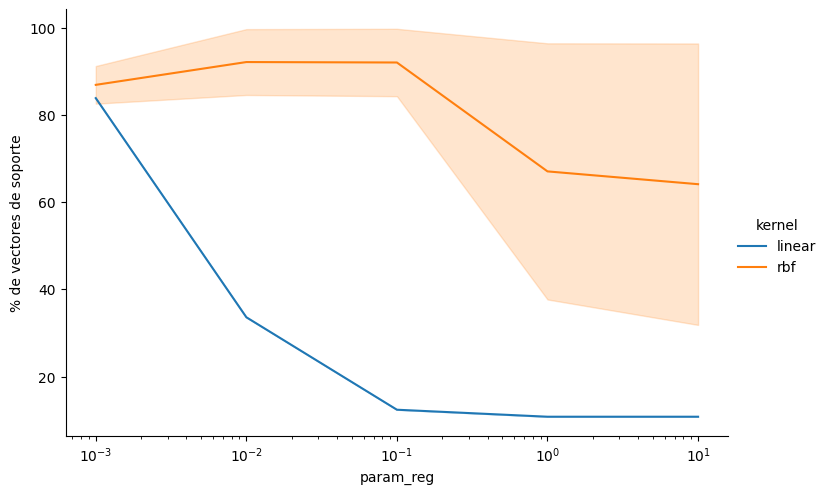

In [255]:
# ver la relación de parametro de regularización y los vectores de soporte
import seaborn as sns
ax= sns.relplot(data = resultadosSVC_ovo, x = 'param_reg', y = '% de vectores de soporte', kind = 'line', hue ='kernel', aspect = 1.5)
ax.set(xscale="log")
plt.show()

In [256]:
#TEACHER
from sklearn.metrics import balanced_accuracy_score
def experiementarSVC(x, y, kernels, gammas,params_reg, estrategia = 'ovo'):
    """función que realizar experimentos sobre un SVM para clasificación

    x: numpy.Array, con los datos de entrada del problema
    y: numpy.Array, con la variable objetivo
    kernels: List[str], lista con valores a pasar
        a sklearn correspondiente al kernel de la SVM
    gammas: List[float], lista con los valores a pasar a
        sklean correspondiente el valor de los coeficientes para usar en el
        kernel
    params_reg: List[float], lista con los valores a a pasar a
        sklearn para ser usados como parametro de regularización
    estrategia: str, valor que puede ser ovo (para one vs one) o ovr
        (para one vs rest)

    retorna: pd.Dataframe con las siguientes columnas:
        - 3 columnas con los tres parametros: kernel, gamma, param de regularizacion
        - estrategia de clasificación (ovo o ovr)
        - Error en el conjunto de entrenamiento (promedio de los 4 folds)
        - Error en el conjunto de test (promedio de los 4 folds)
        - % de Vectores de Soporte promedio para los 4 folds (0 a 100)
    """
    idx = 0
    kf = StratifiedKFold(n_splits=4)
    # crear una lista con la combinaciones de los elementos de cada list
    kernels_gammas_regs = list(itertools.product(kernels, gammas, params_reg))
    resultados = pd.DataFrame()

    for params in kernels_gammas_regs:
        kernel, gamma, param_reg = params
        print("parametros usados", params) # puede usar para ver los params
        errores_train = []
        errores_test = []
        pct_support_vectors = []

        for train_index, test_index in kf.split(x,y):
            X_train, X_test = x[train_index], x[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # normalizar los datos
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            #Instanciar y entrenar el modelo con los hiperparámetros adecuados
            svm = SVC(kernel = kernel, gamma = gamma, C = param_reg, max_iter=500)

            if estrategia == 'ovo':
                svm = OneVsOneClassifier(svm)
            elif estrategia == 'ovr':
                svm = OneVsRestClassifier(svm)
            svm.fit(X=X_train, y=y_train)


            # calculo de errores
            y_train_pred = svm.predict(X_train)
            y_test_pred = svm.predict(X_test)

            # error y pct de vectores de soporte
            errores_train.append(1 - balanced_accuracy_score(y_true = y_train, y_pred = y_train_pred))
            errores_test.append(1 - balanced_accuracy_score(y_true = y_test, y_pred = y_test_pred))

            # Calcular el porcentaje de vectores de soporte. Tenga en cuenta que las estrategias
            # OVO y OVR implican el entrenamiento de varios modelos. En este caso se debe estimar
            # el promedio de porcentajes de vectores de soporte dentro del objeto OVO u OVR.

            _, n_clases= np.unique(y_train,return_counts=True)
            n = X_train.shape[0]
            n_samples = []
            for i in range(len(n_clases)):
              for j in range(i+1,len(n_clases)):
                  n_samples.append(n_clases[i] + n_clases[j])

            num_vs = 0
            if estrategia == 'ovo':
                for i in range(len(svm.estimators_)):
                    num_vs += len(svm.estimators_[i].support_)/n_samples[i]
                pct_vs = (num_vs / len(svm.estimators_)) *100
            elif estrategia == 'ovr':
                for i in range(len(svm.estimators_)):
                    num_vs += len(svm.estimators_[i].support_)
                pct_vs = (num_vs / (len(svm.estimators_)*n)) *100

            pct_support_vectors.append(pct_vs)

        resultados.loc[idx,'kernel'] = kernel
        resultados.loc[idx,'gamma'] = gamma
        resultados.loc[idx,'param_reg'] = param_reg
        resultados.loc[idx,'estrategia'] = estrategia
        resultados.loc[idx,'error de entrenamiento'] = np.mean(errores_train)
        resultados.loc[idx,'error de prueba'] = np.mean(errores_test)
        resultados.loc[idx,'% de vectores de soporte'] = np.mean(pct_support_vectors)
        idx+=1
    return (resultados)

In [257]:
#TEACHER
# vamos a realizar los experimentos
resultadosSVC_ovr = experiementarSVC(x = Xcl,y=Ycl,
                                 kernels=['linear', 'rbf'],
                                 gammas = [0.01,0.1],
                                 params_reg = [0.001, 0.01,0.1, 1.0,10],
                                estrategia = 'ovr')

parametros usados ('linear', 0.01, 0.001)
parametros usados ('linear', 0.01, 0.01)
parametros usados ('linear', 0.01, 0.1)
parametros usados ('linear', 0.01, 1.0)
parametros usados ('linear', 0.01, 10)
parametros usados ('linear', 0.1, 0.001)
parametros usados ('linear', 0.1, 0.01)
parametros usados ('linear', 0.1, 0.1)
parametros usados ('linear', 0.1, 1.0)
parametros usados ('linear', 0.1, 10)
parametros usados ('rbf', 0.01, 0.001)
parametros usados ('rbf', 0.01, 0.01)
parametros usados ('rbf', 0.01, 0.1)
parametros usados ('rbf', 0.01, 1.0)
parametros usados ('rbf', 0.01, 10)
parametros usados ('rbf', 0.1, 0.001)
parametros usados ('rbf', 0.1, 0.01)
parametros usados ('rbf', 0.1, 0.1)
parametros usados ('rbf', 0.1, 1.0)
parametros usados ('rbf', 0.1, 10)


In [259]:
#TEACHER
# ver los mejores modelos
resultadosSVC_ovr.sort_values('error de prueba', ascending=True).head(5)

,kernel,gamma,param_reg,estrategia,error de entrenamiento,error de prueba,% de vectores de soporte
14,rbf,0.01,10.0,ovr,0.000000,0.016655,24.149326
13,rbf,0.01,1.0,ovr,0.000456,0.037446,31.363125
2,linear,0.01,0.1,ovr,0.005286,0.049401,12.014300
7,linear,0.10,0.1,ovr,0.005286,0.049401,12.014300
3,linear,0.01,1.0,ovr,0.002532,0.051354,9.165612


In [2]:
## TEACHER
# --- CREATE or OVERWRITE STUDENTS NOTEBOOK ---
import init
from local.lib.rlxmoocapi import utils
student_notebook_fname = utils.convert_this_notebook_to_student()

<IPython.core.display.Javascript object>

NOTEBOOK name is lab5_parte2--XX--TEACHER--XX.ipynb
student notebook writen to 'lab5_parte2.ipynb'
